In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tutorial de Astropy

**Autor:** Luis Salazar Manzano  
**Última actualización:** Junio 2026 

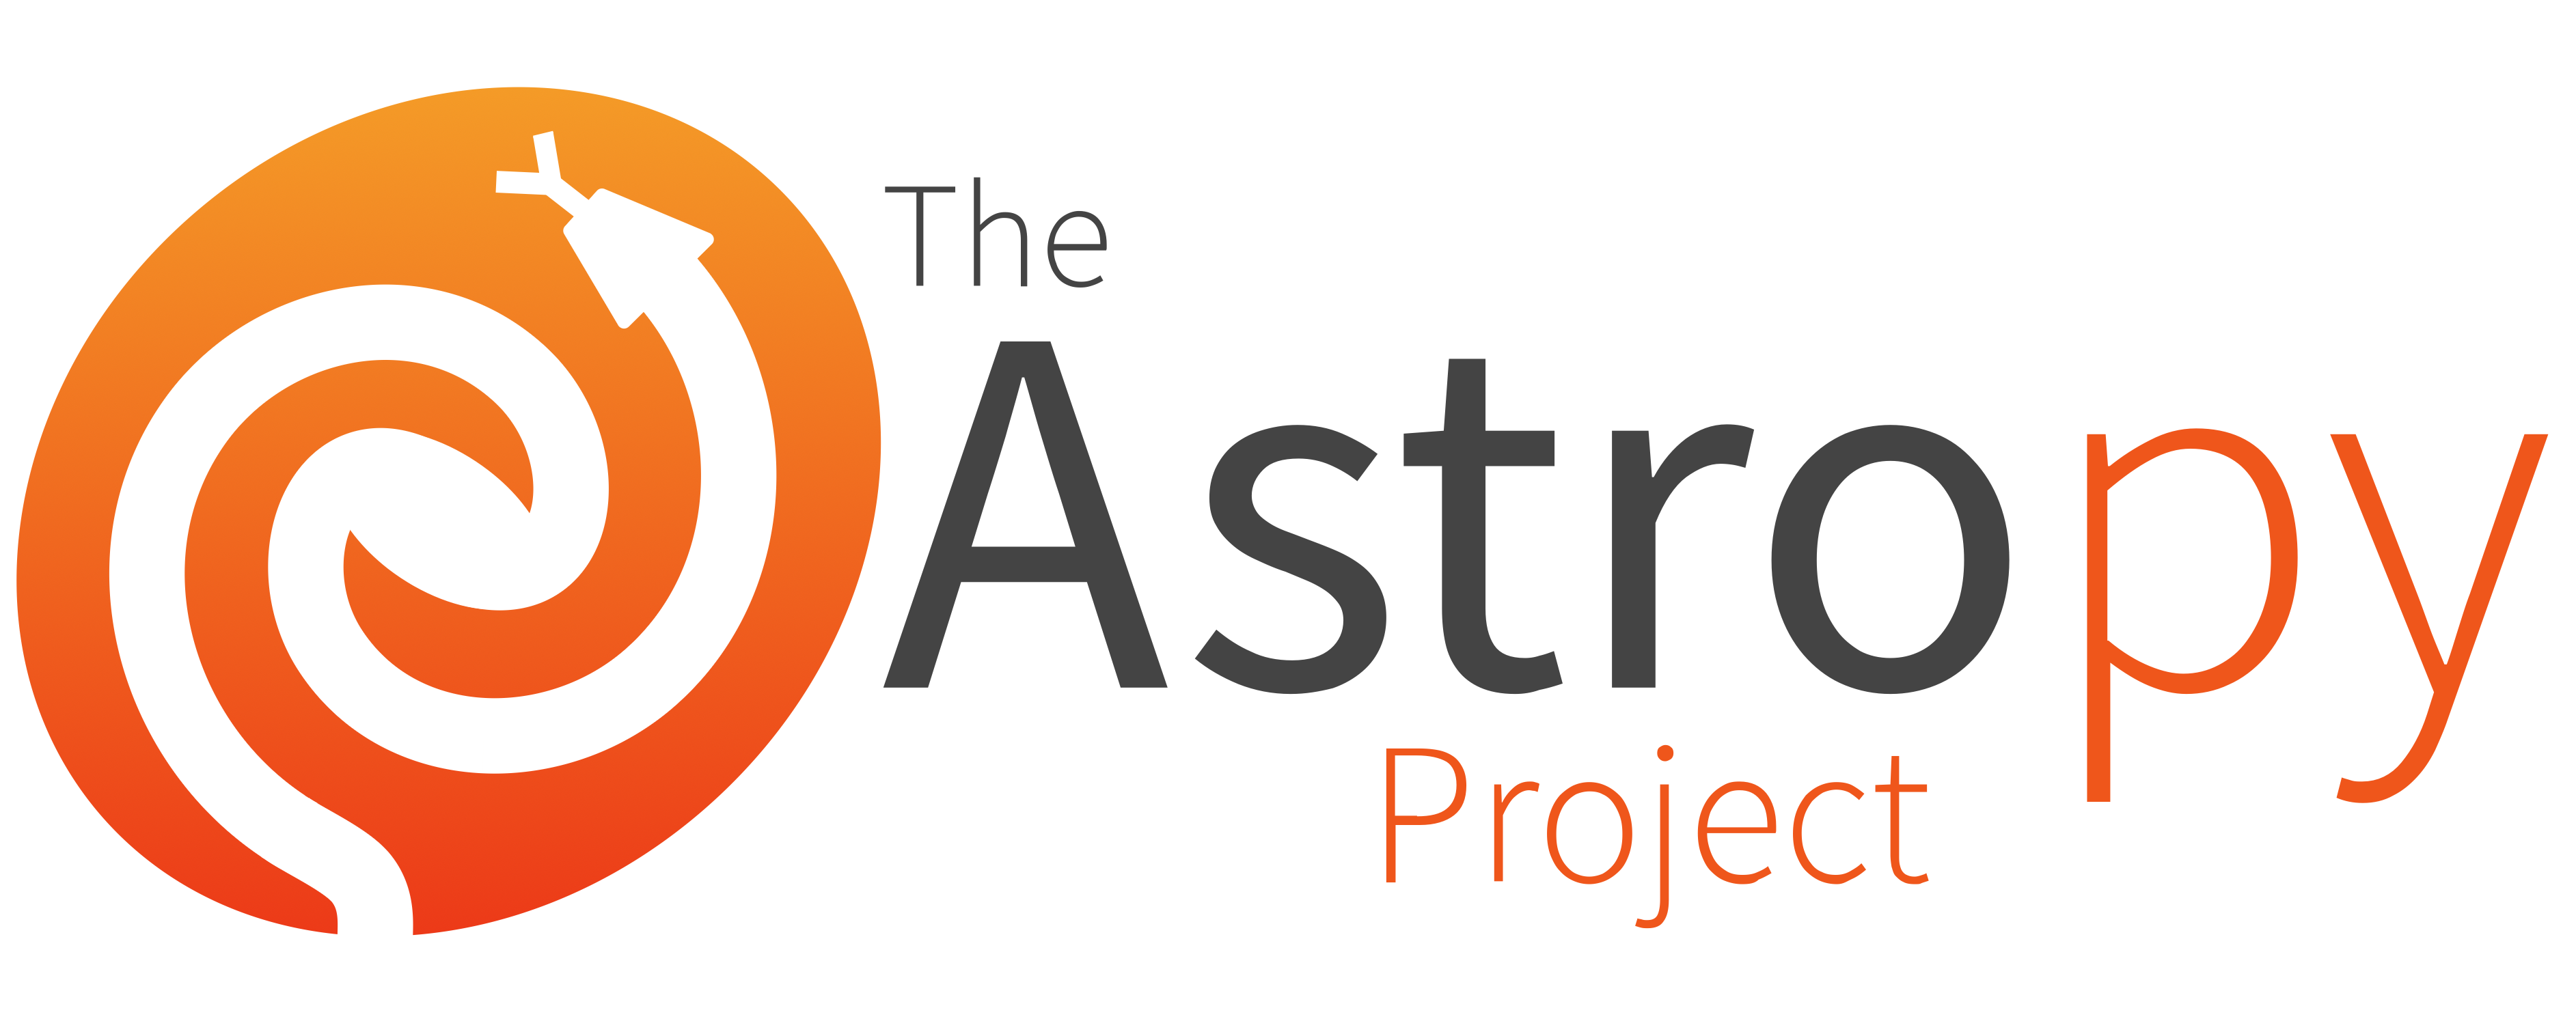

Astropy (https://www.astropy.org/) es un proyecto de código abierto y de desarrollo colaborativo que proporciona una extensa librería en Python para el análisis y procesamiento de datos astronómicos. Su misión es:

- Facilitar a la comunidad científica herramientas homogéneas y bien documentadas.  
- Promover buenas prácticas de programación en astronomía.  
- Fomentar la creación y el mantenimiento de paquetes afines (afiliados).

En este tutorial revisaremos de forma práctica algunos de los módulos centrales de Astropy:

1. **Units** – manejo y conversión de unidades físicas.  
2. **Constants** – constantes físicas con valores oficiales y sus incertidumbres.  
3. **Coordinates/Angle** – representación, formateo y manipulación de ángulos celestes.  
4. **Time** – formatos, escalas y operaciones de tiempo con precisión nanosegundo.  
5. **Coordinates/SkyCoord** – definición y transformación de sistemas de coordenadas celestes.  
6. **IO (FITS)** – lectura y escritura de archivos FITS, headers y tablas.  
7. **WCS** – transformación entre coordenadas de píxeles e “world coordinates” (RA/Dec, espectro, etc.).

Para instalar astropy solo se requiere correr el comando `pip install astropy`.

# Astropy units

`astropy.units` es un paquete muy útil para manipular cantidades físicas al momento de realizar cálculos y operaciones en astronomía. En esta sección del tutorial abordaremos los siguientes elementos:

- Cómo importar el paquete.  
- Las clases `Unit` y `Quantity`, sus atributos principales y la construcción de unidades compuestas.  
- Cómo convertir entre diferentes unidades y sistemas de medida.  
- Operaciones permitidas y no permitidas entre objetos `Quantity`.  
- Interacción de `Quantity` con `numpy` y sus funciones vectorizadas.  
- Dónde encontrar la lista completa de unidades disponibles.  

¡Empecemos!


In [2]:
import astropy.units as u
# from astropy import units as u

Clases Unit y Quantity:

In [3]:
u.AU

Unit("AU")

In [4]:
type(u.AU)

astropy.units.core.Unit

In [5]:
u.AU.physical_type

PhysicalType('length')

In [6]:
distance = 1 * u.AU
distance

<Quantity 1. AU>

In [7]:
type(distance)

astropy.units.quantity.Quantity

In [8]:
distance.value

1.0

In [9]:
distance.unit

Unit("AU")

Conversión de unidades:

In [10]:
distance.to(u.km)

<Quantity 1.49597871e+08 km>

In [11]:
distance.to(u.pc)

<Quantity 4.84813681e-06 pc>

In [12]:
distance.to(u.lyr), distance.to(u.lsec)

(<Quantity 1.58125074e-05 lyr>, <Quantity 499.00478384 lsec>)

In [13]:
# factor de escala
(u.AU).to(u.km)

149597870.7

In [14]:
velocity =  299792458 * u.m / u.s 

In [15]:
velocity.to(u.km / u.h)

<Quantity 1.07925285e+09 km / h>

Operaciones permitidas y no permitidas:

In [16]:
distance**2

<Quantity 1. AU2>

In [17]:
distance2 = 5 * u.AU

In [18]:
distance + distance2

<Quantity 6. AU>

In [19]:
distance + 1.4959787e11 * u.m

<Quantity 2. AU>

In [20]:
distance + velocity

UnitConversionError: Can only apply 'add' function to quantities with compatible dimensions

In [21]:
(distance / velocity).si

<Quantity 499.00478384 s>

In [22]:
distance.to(u.km/u.s)

UnitConversionError: 'AU' (length) and 'km / s' (speed/velocity) are not convertible

Conversión de sistemas de medidas:

In [23]:
# luminosity_array = np.array([1, 10, 100]) * u.Lsun
# luminosity_array
luminosity = 1 * u.Lsun
luminosity

<Quantity 1. solLum>

In [24]:
luminosity.to(u.W)

<Quantity 3.828e+26 W>

In [25]:
luminosity.decompose()

<Quantity 3.828e+26 m2 kg / s3>

In [26]:
luminosity.si

<Quantity 3.828e+26 J / s>

In [27]:
luminosity.cgs

<Quantity 3.828e+33 erg / s>

In [28]:
luminosity.to(u.erg/u.s)

<Quantity 3.828e+33 erg / s>

In [29]:
gravitational = 6.67430e-11 * u.m**3 / (u.kg * u.s**2)
gravitational

<Quantity 6.6743e-11 m3 / (kg s2)>

In [30]:
gravitational.si

<Quantity 6.6743e-11 m3 / (kg s2)>

In [31]:
gravitational.cgs

<Quantity 6.6743e-08 cm3 / (g s2)>

In [32]:
g_earth = gravitational * u.Mearth / u.Rearth**2
g_earth

<Quantity 6.6743e-11 m3 earthMass / (kg earthRad2 s2)>

In [33]:
g_earth.si

<Quantity 9.79839813 m / s2>

In [34]:
F_earth = g_earth * 80 * u.kg
F_earth

<Quantity 5.33944e-09 m3 earthMass / (earthRad2 s2)>

In [35]:
F_earth.to(u.N)

<Quantity 783.87185069 N>

In [36]:
g_jupiter = gravitational * u.Mjupiter / u.Rjupiter**2
g_jupiter.si

<Quantity 24.78651948 m / s2>

In [37]:
F_jupiter = g_jupiter * 80 * u.kg
F_jupiter.to(u.N)

<Quantity 1982.92155809 N>

In [38]:
F_ratio = (F_jupiter / F_earth).si
F_ratio

<Quantity 2.52965017>

In [39]:
type(F_ratio)

astropy.units.quantity.Quantity

In [40]:
F_ratio.value

2.529650167099985

In [41]:
F_ratio.unit

Unit(dimensionless)

Numpy y astropy Quantity

In [42]:
luminosity_array = np.array([1, 10, 100]) * u.Lsun
luminosity_array

<Quantity [  1.,  10., 100.] solLum>

In [43]:
type(luminosity_array)

astropy.units.quantity.Quantity

In [44]:
luminosity_array.value

array([  1.,  10., 100.])

In [45]:
luminosity_array.unit

Unit("solLum")

In [46]:
np.sin(90 * u.deg)

<Quantity 1.>

In [47]:
np.sin((90 * u.deg).to(u.rad))

<Quantity 1.>

In [48]:
np.log10(F_earth)

UnitTypeError: Can only apply 'log10' function to dimensionless quantities

In [49]:
np.log10(F_ratio)

<Quantity 0.40306047>

Existen muchas unidades más: https://docs.astropy.org/en/stable/units/ref_api.html#module-astropy.units.si

In [50]:
u.Msun, u.Lsun, u.Rsun

(Unit("solMass"), Unit("solLum"), Unit("solRad"))

In [51]:
u.M_sun, u.L_sun, u.R_sun

(Unit("solMass"), Unit("solLum"), Unit("solRad"))

In [52]:
u.Msun.aliases

['M_sun', 'Msun']

In [53]:
u.Mjup, u.Rjup, u.Mearth, u.Rearth

(Unit("jupiterMass"), Unit("jupiterRad"), Unit("earthMass"), Unit("earthRad"))

In [54]:
u.Angstrom, u.nm, u.micron, 

(Unit("Angstrom"), Unit("nm"), Unit("micron"))

In [55]:
u.Hz, u.MHz

(Unit("Hz"), Unit("MHz"))

In [56]:
u.deg, u.arcmin, u.arcsec, u.mas, u.sr, u.rad

(Unit("deg"),
 Unit("arcmin"),
 Unit("arcsec"),
 Unit("mas"),
 Unit("sr"),
 Unit("rad"))

In [57]:
u.g, u.kg

(Unit("g"), Unit("kg"))

In [58]:
u.yr, u.d, u.h, u.s

(Unit("yr"), Unit("d"), Unit("h"), Unit("s"))

In [59]:
u.N, u.Pa

(Unit("N"), Unit("Pa"))

Las equivalencias (no cubierto aquí) también son una funcionalidad importante de astropy.units

# Astropy constants

`astropy.constants` complementa a `astropy.units`, facilitando el uso de constantes físicas con valores oficiales e incertidumbres asociadas. En esta sección del tutorial veremos:

- Cómo importar el paquete.  
- Parentescos y diferencias con `astropy.units`.  
- Ejemplos prácticos de constantes comunes (velocidad de la luz, constante gravitatoria, constante de Planck, …).  

Uso básico:

In [60]:
import astropy.constants as const

In [61]:
# from astropy.constants import G

In [62]:
G = const.G
G

<<class 'astropy.constants.codata2018.CODATA2018'> name='Gravitational constant' value=6.6743e-11 uncertainty=1.5e-15 unit='m3 / (kg s2)' reference='CODATA 2018'>

In [63]:
G.value

6.6743e-11

In [64]:
G.unit

Unit("m3 / (kg s2)")

In [65]:
G.uncertainty

1.5e-15

In [66]:
G.cgs

<Quantity 6.6743e-08 cm3 / (g s2)>

In [67]:
gravitational - G

<Quantity 0. m3 / (kg s2)>

In [68]:
c = const.c
c

<<class 'astropy.constants.codata2018.CODATA2018'> name='Speed of light in vacuum' value=299792458.0 uncertainty=0.0 unit='m / s' reference='CODATA 2018'>

In [69]:
velocity - c

<Quantity 0. m / s>

Algunas constantes de ejemplo: https://astro-docs.readthedocs.io/en/latest/constants/index.html

In [70]:
const.L_sun

<<class 'astropy.constants.iau2015.IAU2015'> name='Nominal solar luminosity' value=3.828e+26 uncertainty=0.0 unit='W' reference='IAU 2015 Resolution B 3'>

In [71]:
const.e

<<class 'astropy.constants.codata2018.EMCODATA2018'> name='Electron charge' value=1.602176634e-19 uncertainty=0.0 unit='C' reference='CODATA 2018'>

In [72]:
const.m_e

<<class 'astropy.constants.codata2018.CODATA2018'> name='Electron mass' value=9.1093837015e-31 uncertainty=2.8e-40 unit='kg' reference='CODATA 2018'>

In [73]:
const.k_B

<<class 'astropy.constants.codata2018.CODATA2018'> name='Boltzmann constant' value=1.380649e-23 uncertainty=0.0 unit='J / K' reference='CODATA 2018'>

# Astropy angle

`astropy.coordinates.Angle` es una herramienta esencial para la cotidianidad de los astrónomos, ya que permite trabajar con ángulos en sus diferentes representaciones (grados, radianes, HMS/DMS, …) de forma consistente. En esta sección del tutorial veremos:

- Cómo importar el módulo.  
- Formas de inicializar un objeto `Angle` (valores numéricos, cadenas sexagesimales, arrays).  
- Sus principales atributos (`value`, `unit`, acceso a grados, radianes, DMS/HMS).  
- Métodos y operaciones más comunes (conversión de unidades, formateo a string, wrappings, funciones trigonométricas).  

¡Empecemos!

Importar:

In [74]:
from astropy.coordinates import Angle

Inicialización:

In [75]:
angle_test = Angle(90, u.deg)
angle_test

<Angle 90. deg>

In [76]:
type(angle_test)

astropy.coordinates.angles.core.Angle

In [77]:
angle_test2 = Angle(90 * u.deg)
angle_test2

<Angle 90. deg>

In [78]:
angle_test3 = Angle('12h30m15.5s')
angle_test3

<Angle 12.50430556 hourangle>

Atributos:

In [79]:
angle_test.value

90.0

In [80]:
angle_test.unit

Unit("deg")

In [81]:
angle_test.rad

1.5707963267948966

In [82]:
angle_test.deg

90.0

In [83]:
angle_test.dms

dms_tuple(d=90.0, m=0.0, s=0.0)

In [84]:
angle_test.hms

hms_tuple(h=6.0, m=0.0, s=3.197442310920451e-12)

In [85]:
angle_test.arcsec

324000.0

In [86]:
angles_test = Angle(np.arange(0, 360, 10), u.deg)
angles_test.deg

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300., 310., 320.,
       330., 340., 350.])

Operaciones

In [87]:
np.sin(angle_test)

<Quantity 1.>

In [88]:
angle_test + 60 * u.arcsec

<Angle 90.01666667 deg>

Metodos:

In [89]:
angle_test.to_string(unit=u.deg)

'90d00m00s'

In [90]:
angle_test.to_string(unit=u.deg, sep=":")

'90:00:00'

In [91]:
angle_test.to_string(unit=u.deg, sep=":", precision=2)

'90:00:00.00'

In [92]:
angle_test.to_string(unit=u.hourangle)

'6h00m00s'

In [93]:
angle_test.to_string(unit=u.rad)

'1.5708 rad'

In [94]:
angle_test.to_string(unit=u.arcsec)

'324000 arcsec'

In [95]:
large_angle = Angle(400 * u.deg)
large_angle

<Angle 400. deg>

In [96]:
large_angle.wrap_at(360 * u.deg)

<Angle 40. deg>

# Astropy Time

`astropy.time.Time` es un submódulo muy usada para representar y manipular instantes y duraciones con alta precisión, múltiples escalas y formatos. En esta sección del tutorial revisaremos:

- Cómo importar `Time`.  
- Formas de inicializar objetos `Time` (ISO, JD, MJD, arrays).  
- Escalas de tiempo (UTC, TDB, …) y sus parámetros principales.  
- Atributos útiles (`iso`, `jd`, `mjd`, `ymdhms`).  
- Operaciones típicas: diferencias, sumas, conversiones de escala y formato.  

Importar:

In [97]:
from astropy.time import Time

Inicialización y atributos:

In [98]:
time_test = Time("2025-06-01 12:00:00", format='iso', scale='utc')
time_test

<Time object: scale='utc' format='iso' value=2025-06-01 12:00:00.000>

In [99]:
type(time_test)

astropy.time.core.Time

In [100]:
# format
time_test.jd, time_test.mjd, time_test.iso, time_test.isot

(2460828.0, 60827.5, '2025-06-01 12:00:00.000', '2025-06-01T12:00:00.000')

In [101]:
Time.FORMATS

{'jd': astropy.time.formats.TimeJD,
 'mjd': astropy.time.formats.TimeMJD,
 'decimalyear': astropy.time.formats.TimeDecimalYear,
 'unix': astropy.time.formats.TimeUnix,
 'unix_tai': astropy.time.formats.TimeUnixTai,
 'cxcsec': astropy.time.formats.TimeCxcSec,
 'gps': astropy.time.formats.TimeGPS,
 'plot_date': astropy.time.formats.TimePlotDate,
 'stardate': astropy.time.formats.TimeStardate,
 'datetime': astropy.time.formats.TimeDatetime,
 'ymdhms': astropy.time.formats.TimeYMDHMS,
 'iso': astropy.time.formats.TimeISO,
 'isot': astropy.time.formats.TimeISOT,
 'yday': astropy.time.formats.TimeYearDayTime,
 'datetime64': astropy.time.formats.TimeDatetime64,
 'fits': astropy.time.formats.TimeFITS,
 'byear': astropy.time.formats.TimeBesselianEpoch,
 'jyear': astropy.time.formats.TimeJulianEpoch,
 'byear_str': astropy.time.formats.TimeBesselianEpochString,
 'jyear_str': astropy.time.formats.TimeJulianEpochString}

In [102]:
time_test.ymdhms

(2025, 6, 1, 12, 0, 0.)

In [103]:
# scale
time_test.tdb, time_test.tt, time_test.utc

(<Time object: scale='tdb' format='iso' value=2025-06-01 12:01:09.185>,
 <Time object: scale='tt' format='iso' value=2025-06-01 12:01:09.184>,
 <Time object: scale='utc' format='iso' value=2025-06-01 12:00:00.000>)

In [104]:
Time.SCALES

('tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc', 'local')

In [105]:
time_test.tdb.jd, time_test.tdb.mjd, time_test.tdb.iso

(2460828.000800751, 60827.50080075104, '2025-06-01 12:01:09.185')

In [106]:
time_test2 = Time(2460828.000800751, format="jd", scale="tdb")
time_test2

<Time object: scale='tdb' format='jd' value=2460828.000800751>

Operaciones

In [107]:
time_test + 1 * u.d

<Time object: scale='utc' format='iso' value=2025-06-02 12:00:00.000>

In [108]:
time_test + np.arange(0, 10) * u.d

<Time object: scale='utc' format='iso' value=['2025-06-01 12:00:00.000' '2025-06-02 12:00:00.000'
 '2025-06-03 12:00:00.000' '2025-06-04 12:00:00.000'
 '2025-06-05 12:00:00.000' '2025-06-06 12:00:00.000'
 '2025-06-07 12:00:00.000' '2025-06-08 12:00:00.000'
 '2025-06-09 12:00:00.000' '2025-06-10 12:00:00.000']>

In [109]:
Time.now()

<Time object: scale='utc' format='datetime' value=2026-06-20 12:52:59.080837>

In [110]:
time_test - (time_test + 1 * u.d)

<TimeDelta object: scale='tai' format='jd' value=-1.0>

In [111]:
time_test.sidereal_time('apparent', longitude=-74*u.deg)

<Longitude 23.74837655 hourangle>

In [112]:
Time(['2026-01-01', '2026-06-01', '2026-12-01'], format='iso', scale='utc')

<Time object: scale='utc' format='iso' value=['2026-01-01 00:00:00.000' '2026-06-01 00:00:00.000'
 '2026-12-01 00:00:00.000']>

# Astropy SkyCoord

`astropy.coordinates.SkyCoord` es quizás uno de los submódulos más utilizados de todo astropy, ya que cualquier objeto celeste se describe mediante coordenadas en la esfera celeste. En esta sección abordaremos:

- Cómo importar el módulo `SkyCoord`.  
- Cómo inicializar un objeto `SkyCoord` y cuáles son sus atributos principales.  
- Las diferentes representaciones y sistemas de referencia, y cómo transformarlos.  
- Algunos métodos comunes (por ejemplo, `separation()`,  `match_to_catalog_sky()`).  
- Cómo transformar coordenadas a un sistema local (AltAz), combinando `SkyCoord`, `Time` y `EarthLocation`.  

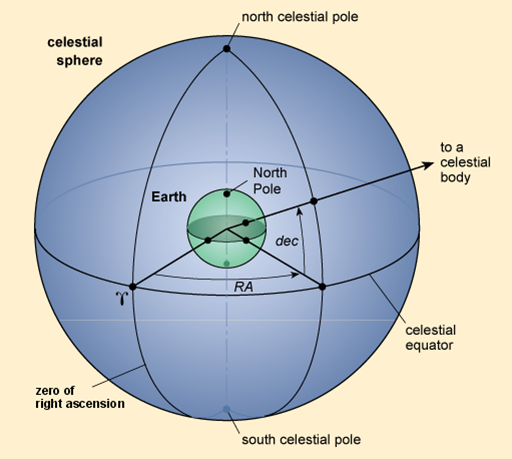

Importar:

In [113]:
from astropy.coordinates import SkyCoord

Inicialización y atributos:

In [114]:
coord1 = SkyCoord(ra=270*u.deg, dec=25*u.deg, frame="icrs")

In [115]:
type(coord1)

astropy.coordinates.sky_coordinate.SkyCoord

In [116]:
coord1.ra

<Longitude 270. deg>

In [117]:
coord1.dec

<Latitude 25. deg>

In [118]:
coord1.frame

<ICRS Coordinate: (ra, dec) in deg
    (270., 25.)>

In [119]:
coord1 = SkyCoord(270, 25, unit=(u.deg, u.deg), frame="icrs" )
coord1

<SkyCoord (ICRS): (ra, dec) in deg
    (270., 25.)>

In [120]:
coord1 = SkyCoord("12h30m25s -15d30m10s", frame="icrs")
coord1

<SkyCoord (ICRS): (ra, dec) in deg
    (187.60416667, -15.50277778)>

In [121]:
coord_array = SkyCoord(np.linspace(0, 360, 20), np.linspace(-90, 90, 20), unit=(u.deg, u.deg), frame="icrs")
coord_array

<SkyCoord (ICRS): (ra, dec) in deg
    [(  0.        , -90.        ), ( 18.94736842, -80.52631579),
     ( 37.89473684, -71.05263158), ( 56.84210526, -61.57894737),
     ( 75.78947368, -52.10526316), ( 94.73684211, -42.63157895),
     (113.68421053, -33.15789474), (132.63157895, -23.68421053),
     (151.57894737, -14.21052632), (170.52631579,  -4.73684211),
     (189.47368421,   4.73684211), (208.42105263,  14.21052632),
     (227.36842105,  23.68421053), (246.31578947,  33.15789474),
     (265.26315789,  42.63157895), (284.21052632,  52.10526316),
     (303.15789474,  61.57894737), (322.10526316,  71.05263158),
     (341.05263158,  80.52631579), (  0.        ,  90.        )]>

Sistemas de coordenadas:

In [122]:
coord1.cartesian.xyz.value

array([-0.95514337, -0.12751403, -0.26728509])

In [123]:
coord1.cylindrical

<CylindricalRepresentation (rho, phi, z) in (, deg, )
    (0.9636175, -172.39583333, -0.26728509)>

In [124]:
coord1.spherical

<SphericalRepresentation (lon, lat, distance) in (deg, deg, )
    (187.60416667, -15.50277778, 1.)>

Marcos de referencia:

In [125]:
coord1.galactic

<SkyCoord (Galactic): (l, b) in deg
    (295.48698267, 47.0648703)>

In [126]:
coord1.galactic.l

<Longitude 295.48698267 deg>

In [127]:
coord1.galactic.b

<Latitude 47.0648703 deg>

In [128]:
from astropy.coordinates import Galactic
coord1.transform_to(Galactic())

<SkyCoord (Galactic): (l, b) in deg
    (295.48698267, 47.0648703)>

In [129]:
coord3 = SkyCoord(np.linspace(0, 360, 100)*u.deg, np.zeros(100)*u.deg, frame="galactic")
coord3

<SkyCoord (Galactic): (l, b) in deg
    [(  0.        , 0.), (  3.63636364, 0.), (  7.27272727, 0.),
     ( 10.90909091, 0.), ( 14.54545455, 0.), ( 18.18181818, 0.),
     ( 21.81818182, 0.), ( 25.45454545, 0.), ( 29.09090909, 0.),
     ( 32.72727273, 0.), ( 36.36363636, 0.), ( 40.        , 0.),
     ( 43.63636364, 0.), ( 47.27272727, 0.), ( 50.90909091, 0.),
     ( 54.54545455, 0.), ( 58.18181818, 0.), ( 61.81818182, 0.),
     ( 65.45454545, 0.), ( 69.09090909, 0.), ( 72.72727273, 0.),
     ( 76.36363636, 0.), ( 80.        , 0.), ( 83.63636364, 0.),
     ( 87.27272727, 0.), ( 90.90909091, 0.), ( 94.54545455, 0.),
     ( 98.18181818, 0.), (101.81818182, 0.), (105.45454545, 0.),
     (109.09090909, 0.), (112.72727273, 0.), (116.36363636, 0.),
     (120.        , 0.), (123.63636364, 0.), (127.27272727, 0.),
     (130.90909091, 0.), (134.54545455, 0.), (138.18181818, 0.),
     (141.81818182, 0.), (145.45454545, 0.), (149.09090909, 0.),
     (152.72727273, 0.), (156.36363636, 0.), (160.    

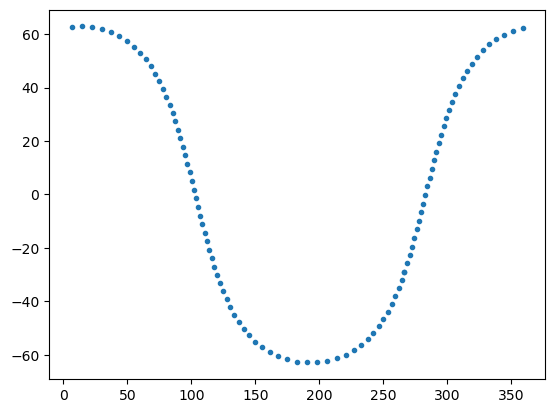

In [130]:
plt.plot(coord3.icrs.ra.deg, coord3.icrs.dec.deg, '.')

In [131]:
coord1.fk4

<SkyCoord (FK4: equinox=B1950.000, obstime=B1950.000): (ra, dec) in deg
    (186.95381998, -15.22660019)>

Algunos metodos:

In [132]:
coord1.to_string('hmsdms')

'12h30m25s -15d30m10s'

In [133]:
coord1.to_string('dms')

'187d36m15s -15d30m10s'

In [134]:
coord1.separation(coord_array).deg

array([ 74.49722222,  83.79238062,  90.99513932,  93.69119326,
        90.51655483,  81.63012434,  68.30700598,  52.13025104,
        34.80486363,  19.93929846,  20.32411072,  36.14398929,
        55.18274276,  74.17086897,  91.69060058, 106.20161415,
       115.65200655, 118.17147077, 113.92359955, 105.50277778])

In [135]:
# match_to_catalog_sky()

Coordenadas locales:

In [136]:
from astropy.coordinates import AltAz, EarthLocation

In [137]:
decam = EarthLocation.of_site("Kitt Peak")
decam

<EarthLocation (-1994502.60430614, -5037538.54232911, 3358104.99690298) m>

In [138]:
decam.geocentric

(<Quantity -1994502.60430614 m>,
 <Quantity -5037538.54232911 m>,
 <Quantity 3358104.99690298 m>)

In [139]:
decam.geodetic

GeodeticLocation(lon=<Longitude -111.6 deg>, lat=<Latitude 31.96333333 deg>, height=<Quantity 2120. m>)

In [140]:
EarthLocation.get_site_names()

['ALMA',
 'AO',
 'ARCA',
 'ASKAP',
 'ATA',
 'ATST',
 'Allen Telescope Array',
 'Anderson Mesa',
 'Anglo-Australian Observatory',
 'Apache Point',
 'Apache Point Observatory',
 'Arecibo',
 'Arecibo Observatory',
 'Astroparticle Research with Cosmics in the Abyss',
 'Atacama Large Millimeter Array',
 'Australian Square Kilometre Array Pathfinder',
 'BAO',
 'BBSO',
 'Beijing XingLong Observatory',
 'Big Bear Solar Observatory',
 'Black Moshannon Observatory',
 'CAHA',
 'CAHA',
 'CHARA',
 'CHIME',
 'Canada-France-Hawaii Telescope',
 'Canadian Hydrogen Intensity Mapping Experiment',
 'Catalina Observatory',
 'Catalina Observatory: 61 inch telescope',
 'Centro Astronomico Hispano-Aleman, Almeria',
 'Cerro Armazones Observatory',
 'Cerro Pachon',
 'Cerro Paranal',
 'Cerro Tololo',
 'Cerro Tololo Interamerican Observatory',
 'Cima Ekar 182 cm Telescope',
 'Cima Ekar Observing Station',
 'DCT',
 'DKIST',
 'DRAO',
 'DRAO 26m Telescope',
 'Daniel K. Inouye Solar Telescope',
 'Discovery Channel Te

In [141]:
observatory = AltAz(location=decam, obstime=time_test)
observatory

<AltAz Frame (obstime=2025-06-01 12:00:00.000, location=(-1994502.60430614, -5037538.54232911, 3358104.99690298) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron)>

In [142]:
coord1_altaz = coord1.transform_to(observatory)

In [143]:
coord1_altaz

<SkyCoord (AltAz: obstime=2025-06-01 12:00:00.000, location=(-1994502.60430614, -5037538.54232911, 3358104.99690298) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (278.07091633, -42.48302798)>

In [144]:
coord1_altaz.alt

<Latitude -42.48302798 deg>

In [145]:
coord1_altaz.az

<Longitude 278.07091633 deg>

In [146]:
coord1_altaz

<SkyCoord (AltAz: obstime=2025-06-01 12:00:00.000, location=(-1994502.60430614, -5037538.54232911, 3358104.99690298) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (278.07091633, -42.48302798)>

# Astropy Fits

Los archivos **FITS** (Flexible Image Transport System) son el estándar en astronomía para el almacenamiento de datos científicos. Un fichero FITS consta de:

- **Encabezado (header):** contiene metadatos (fecha, instrumento, condiciones de observación, WCS, unidades, etc.).  
- **Datos:** matriz con valores que representan imágenes, cubos, espectros o tablas.

Aunque FITS soporta distintos tipos de extensiones (imágenes, espectros, tablas…), en esta sección nos centraremos en imágenes y veremos:

- Cómo importar `astropy.io.fits`.  
- Cómo abrir un archivo FITS y explorar su encabezado y datos.  
- Cómo editar el header y procesar la matriz de la imagen.  
- Cómo visualizar una imagen FITS con `matplotlib`.  


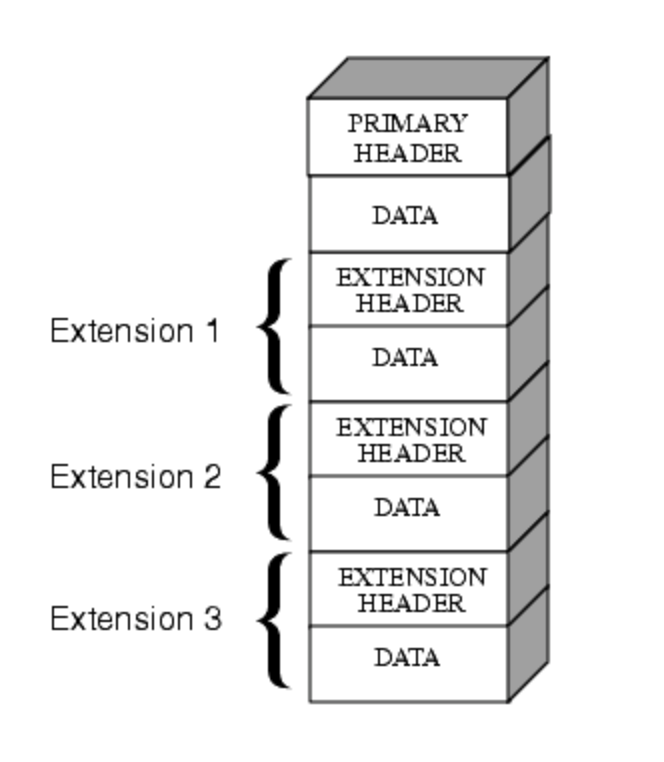

In [147]:
from astropy.io import fits

In [148]:
# image_file = fits.util.get_testdata_filepath('test1.fits')			
# image_file

In [149]:
# from astropy.utils.data import download_file
# image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)
image_file = 'image_example.fits'

In [150]:
# HDUL (Header/Data Unit List)
hdul = fits.open(image_file)
# hdul = fits.open('example2.fits')

In [151]:
hdul.info()

Filename: image_example.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


In [152]:
hdul[0].header

SIMPLE  =                    T /FITS: Compliance                                
BITPIX  =                   16 /FITS: I*2 Data                                  
NAXIS   =                    2 /FITS: 2-D Image Data                            
NAXIS1  =                  891 /FITS: X Dimension                               
NAXIS2  =                  893 /FITS: Y Dimension                               
EXTEND  =                    T /FITS: File can contain extensions               
DATE    = '2014-01-09        '  /FITS: Creation Date                            
ORIGIN  = 'STScI/MAST'         /GSSS: STScI Digitized Sky Survey                
SURVEY  = 'SERC-ER '           /GSSS: Sky Survey                                
REGION  = 'ER768   '           /GSSS: Region Name                               
PLATEID = 'A0JP    '           /GSSS: Plate ID                                  
SCANNUM = '01      '           /GSSS: Scan Number                               
DSCNDNUM= '00      '        

In [153]:
list(hdul[0].header.keys())

['SIMPLE',
 'BITPIX',
 'NAXIS',
 'NAXIS1',
 'NAXIS2',
 'EXTEND',
 'DATE',
 'ORIGIN',
 'SURVEY',
 'REGION',
 'PLATEID',
 'SCANNUM',
 'DSCNDNUM',
 'TELESCID',
 'BANDPASS',
 'COPYRGHT',
 'SITELAT',
 'SITELONG',
 'TELESCOP',
 'INSTRUME',
 'EMULSION',
 'FILTER',
 'PLTSCALE',
 'PLTSIZEX',
 'PLTSIZEY',
 'PLATERA',
 'PLATEDEC',
 'PLTLABEL',
 'DATE-OBS',
 'EXPOSURE',
 'PLTGRADE',
 'OBSHA',
 'OBSZD',
 'AIRMASS',
 'REFBETA',
 'REFBETAP',
 'REFK1',
 'REFK2',
 'CNPIX1',
 'CNPIX2',
 'XPIXELS',
 'YPIXELS',
 'XPIXELSZ',
 'YPIXELSZ',
 'PPO1',
 'PPO2',
 'PPO3',
 'PPO4',
 'PPO5',
 'PPO6',
 'PLTRAH',
 'PLTRAM',
 'PLTRAS',
 'PLTDECSN',
 'PLTDECD',
 'PLTDECM',
 'PLTDECS',
 'EQUINOX',
 'AMDX1',
 'AMDX2',
 'AMDX3',
 'AMDX4',
 'AMDX5',
 'AMDX6',
 'AMDX7',
 'AMDX8',
 'AMDX9',
 'AMDX10',
 'AMDX11',
 'AMDX12',
 'AMDX13',
 'AMDX14',
 'AMDX15',
 'AMDX16',
 'AMDX17',
 'AMDX18',
 'AMDX19',
 'AMDX20',
 'AMDY1',
 'AMDY2',
 'AMDY3',
 'AMDY4',
 'AMDY5',
 'AMDY6',
 'AMDY7',
 'AMDY8',
 'AMDY9',
 'AMDY10',
 'AMDY11',
 'AMDY

In [154]:
hdul[0].header['TELESCOP']

'UK Schmidt - Doubl'

In [155]:
hdul[0].header['DATE-OBS']

'1990-12-22T13:49:00'

In [156]:
hdul[1].header

XTENSION= 'TABLE   '           / ASCII table extension                          
BITPIX  =                    8 / 8 bit bytes                                    
NAXIS   =                    2 / 2-dimensional ASCII table                      
NAXIS1  =                   24 / Width of table in bytes                        
NAXIS2  =                 1600 / Number of rows in table                        
PCOUNT  =                    0 / Size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                    4 / Number of fields in each row                   
EXTNAME = 'er.mask '           /FITS: Name of Table                             
TTYPE1  = 'XI      '           /                                                
TBCOL1  =                    1 /                                                
TFORM1  = 'F6.2    '           /                                                
TUNIT1  = 'DEGREES '        

In [157]:
hdul[0].data

array([[ 7201,  6642,  6642, ...,  9498,  9498, 10057],
       [ 6642,  6363,  6642, ..., 10057, 10616, 10616],
       [ 6922,  6642,  6922, ..., 10337, 11175, 10616],
       ...,
       [ 5412,  5132,  5412, ..., 13000, 12580, 12021],
       [ 5796,  5517,  5796, ..., 12546, 12546, 11987],
       [ 5796,  5796,  6076, ..., 11987, 12546, 12546]], dtype='>i2')

In [158]:
np.shape(hdul[0].data)

(893, 891)

(array([1.0000e+00, 0.0000e+00, 1.0000e+00, 3.0000e+00, 1.1000e+01,
        5.4000e+01, 8.9000e+01, 2.3800e+02, 4.1200e+02, 7.8400e+02,
        1.5120e+03, 2.1850e+03, 3.1780e+03, 4.5050e+03, 5.9400e+03,
        7.3260e+03, 8.4820e+03, 1.0097e+04, 1.0967e+04, 1.1582e+04,
        1.2318e+04, 1.2906e+04, 1.3776e+04, 1.5006e+04, 1.5104e+04,
        1.5466e+04, 1.4965e+04, 1.5350e+04, 1.5368e+04, 1.5649e+04,
        1.4748e+04, 1.4342e+04, 1.3449e+04, 1.3236e+04, 1.2290e+04,
        1.1406e+04, 1.0324e+04, 9.7210e+03, 9.3560e+03, 8.8580e+03,
        8.3650e+03, 7.6280e+03, 6.3630e+03, 6.4180e+03, 5.9210e+03,
        5.3740e+03, 5.1450e+03, 4.7800e+03, 4.7160e+03, 4.4620e+03,
        4.4000e+03, 4.6070e+03, 4.5240e+03, 4.9700e+03, 5.3870e+03,
        5.7630e+03, 6.6630e+03, 7.6390e+03, 7.5710e+03, 8.4100e+03,
        8.3910e+03, 8.8710e+03, 9.1150e+03, 9.5310e+03, 9.3400e+03,
        9.2860e+03, 9.3950e+03, 9.7330e+03, 9.6110e+03, 1.0134e+04,
        9.7200e+03, 1.0164e+04, 1.0470e+04, 1.06

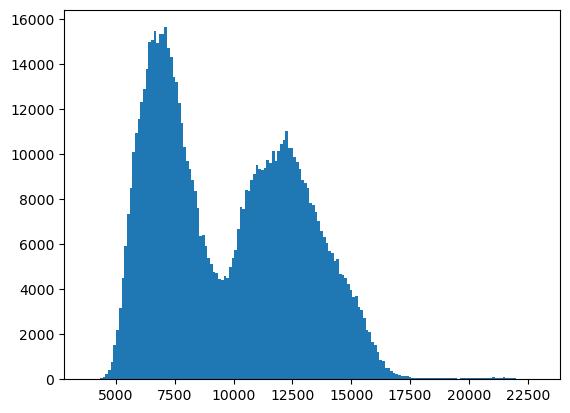

In [159]:
plt.hist(hdul[0].data.flatten(), bins='scott')

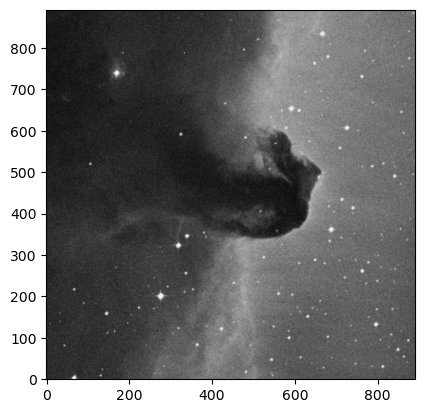

In [160]:
plt.imshow(hdul[0].data, origin='lower', cmap='gray')
# plt.imshow(hdul[0].data, origin='lower', cmap='gray', vmin=300, vmax=325)

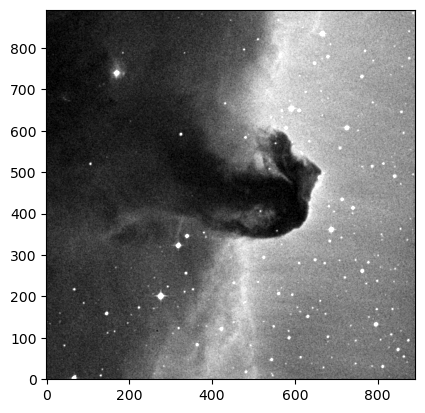

In [161]:
plt.imshow(hdul[0].data, origin='lower', cmap='gray', vmin=5000, vmax=17000)

In [162]:
# Notes: 
# - Headers are like python dictionaries.
# - Use the with statement to open files, so they are closed automatically.

# Astropy WCS

El World Coordinate System (WCS) define las convenciones para transformar coordenadas de píxeles en un archivo FITS a coordenadas espaciales (RA/Dec), espectrales o temporales. En esta última parte del tutorial abordaremos:

- Cómo importar `astropy.wcs`.  
- Cómo construir un objeto `WCS` a partir del header de un archivo FITS.  
- Cómo convertir entre coordenadas de píxeles y coordenadas “world” (pixel ↔ world).  
- Cómo superponer la grilla de coordenadas en una imagen con `matplotlib`.  


In [163]:
from astropy.wcs import WCS

In [164]:
wcs = WCS(hdul[0].header)

In [165]:
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 85.59941666666666 -4.946638888888889 
CRPIX : -716.333144294269 -8444.64946698226 
PC1_1 PC1_2  : 0.015029018460682027 -9.63735777657198e-06 
PC2_1 PC2_2  : 1.0548917307845708e-05 0.015000473845055023 
CDELT : -0.018654788242111486 0.018654788242111486 
NAXIS : 891  893

In [166]:
pixel_coord = wcs.pixel_to_world(10, 5)
pixel_coord

<SkyCoord (ICRS): (ra, dec) in deg
    (85.39691789, -2.58181403)>

In [167]:
wcs.world_to_pixel(pixel_coord)

(array(10.), array(5.))

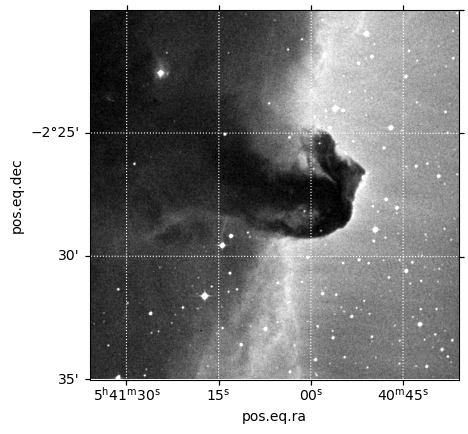

In [168]:
fig, ax = plt.subplots(subplot_kw={'projection': wcs})
ax.imshow(hdul[0].data, origin='lower', cmap='gray', vmin=5000, vmax=17000)
ax.grid(color='white', ls='dotted')

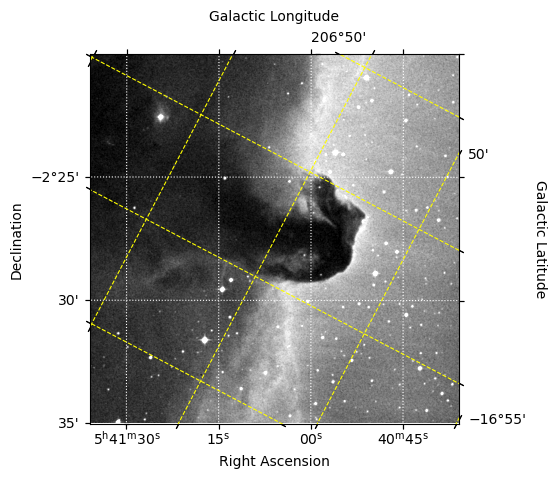

In [169]:
fig, ax = plt.subplots(subplot_kw={'projection': wcs})
ax.imshow(hdul[0].data, origin='lower', cmap='gray', vmin=5000, vmax=17000)
ax.grid(color='white', ls='dotted')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
overlay = ax.get_coords_overlay('galactic')
overlay.grid(color='yellow', ls='dashed')
overlay[0].set_axislabel('Galactic Longitude')
overlay[1].set_axislabel('Galactic Latitude')

# Notas finales

Lo mostrado hasta aquí no cubre de forma exhaustiva todas las funcionalidades de los paquetes mencionados, ni incluye muchos otros submódulos de Astropy muy valiosos para la comunidad astronómica, como:

- **Table**: estructuras de datos tabulares y operaciones avanzadas.  
- **Modeling**: definición, combinación y ajuste de modelos físicos o empíricos.  
- **Timeseries**: lectura, manipulación y análisis de datos en forma de series temporales.  
- **LombScargle**: generación de periodogramas para detección de señales periódicas en datos irregulares.  
- **Astroquery**: consultas programáticas a servicios y catálogos astronómicos en línea.  


Finalmente, algunas referencias para ampliar la información aquí presentada:

- Documentación oficial de astropy: https://docs.astropy.org/en/stable/index_user_docs.html
- Tutorial de astropy por el profesor Germán Chaparro: https://github.com/saint-germain/astropy/tree/master
- Mini workshop de astropy: https://github.com/heliophysicsPy/summer-school/tree/main/astropy-tutorial